# 3 文本张量表示方法

### 学习目标
* 了解什么是文本张量表示及其作用.
* 掌握文本张量表示的几种方法及其实现.

---

## 1 文本张量表示

* 将一段文本使用张量进行表示，其中一般将词汇为表示成向量，称作词向量，再由各个词向量按顺序组成矩阵形成文本表示.
* 举个例子：

> ["人生", "该", "如何", "起头"]
> 
> ==>
> 
> # 每个词对应矩阵中的一个向量
> [[1.32, 4.32, 0.32, 5.2],
>  [3.1, 5.43, 0.34, 3.2],
>  [3.21, 5.32, 2, 4.32],
>  [2.54, 7.32, 5.12, 9.54]]

* **文本张量表示的作用：**
    * 将文本表示成张量（矩阵）形式，能够使语言文本可以作为计算机处理程序的输入，进行接下来一系列的解析工作。
* **文本张量表示的方法：**
    * one-hot编码
    * Word2vec
    * Word Embedding

## 2 one-hot词向量表示

* **又称独热编码**，将每个词表示成具有n个元素的向量，这个词向量中只有一个元素是1，其他元素都是0，不同词汇元素为0的位置不同，其中n的大小是整个语料中不同词汇的总数.
* **举个例子**：

> ["改变", "要", "如何", "起手"]
> 
> ==>
> 
> [[1, 0, 0, 0],
>
>  [0, 1, 0, 0],
>
>  [0, 0, 1, 0],
>
>  [0, 0, 0, 1]]

* **onehot编码实现**：
    * 进行onehot编码：

In [1]:
# 导入用于对象保存与加载的joblib
import joblib

# 导入keras中的词汇映射器Tokenizer
from keras.preprocessing.text import Tokenizer

# 假定vocab为语料集所有不同词汇集合
vocab = {"周杰伦", "陈奕迅", "王力宏", "李宗盛", "吴亦凡", "鹿晗"}

# 实例化一个词汇映射器对象
t = Tokenizer(num_words=None, char_level=False)

# 使用映射器拟合现有文本数据
t.fit_on_texts(vocab)

for token in vocab:
    zero_list = [0]*len(vocab)
    # 使用映射器转化现有文本数据，每个词汇对应从1开始的自然数
    # 返回样式如：[[2]]，取出其中的数字需要使用[0][0]
    token_index = t.texts_to_sequences([token])[0][0] - 1
    zero_list[token_index] = 1
    print(token, "的one-hot编码为:", zero_list)

# 使用joblib工具保存映射器，以便之后使用
tokenizer_path = "./Tokenizer"
joblib.dump(t, tokenizer_path)

ModuleNotFoundError: No module named 'tensorflow'

- 输出效果：

> 鹿晗 的 one-hot编码为：[[1, 0, 0, 0, 0, 0]]
> 
> 王力宏 的 one-hot编码为：[[0, 1, 0, 0, 0, 0]]
> 
> 李宗盛 的 one-hot编码为：[[0, 0, 1, 0, 0, 0]]
> 
> 陈奕迅 的 one-hot编码为：[[0, 0, 0, 1, 0, 0]]
> 
> 周杰伦 的 one-hot编码为：[[0, 0, 0, 0, 1, 0]]
> 
> 吴亦凡 的 one-hot编码为：[[0, 0, 0, 0.1, 0, 1]]
> 
> 同时在当前目录生成Tokenizer文件，以便之后使用

- onehot编码器的使用：

In [ ]:
# 加载之前保存的Tokenizer，实例化一个t对象
t = joblib.load(tokenizer_path)

# 编码token为“李宗盛”
token = "李宗盛"
# 使用t获得token_index
token_index = t.texts_to_sequences([token])[0][0] - 1
# 初始化一个zero_list
zero_list = [0]*len(vocab)
# 令zero_list的对应索引为1
zero_list[token_index] = 1
print(token, "的one-hot编码为:", zero_list)

- 输出效果：

李宗盛的 one-hot编码为：[[1, 0, 0, 0, 0, 0]]

- one-hot编码的优劣劣势：
  - 优势：操作简单，容易理解。
  - 劣势：完全割裂了词与词之间的联系，而且在大语料集下，每个向量的长度过大，占据大量内存。
  - 正因为one-hot编码明显的劣势，这种编码方式被应用的地方越来越少，取而代之的是接下来我们要学习的稠密向量的表示方法word2vec和word embedding。

# 3 word2vec模型

## 3.1 模型介绍

- word2vec是一种流行的将词汇表示成向量的无监督训练方法，该过程将构建神经网络模型，将网络参数作为词汇的向量表示，它包含CBOW和skipgram两种训练模式。

- CBOW(Continuous bag of words)模式：
  - 给定一段用于训练的文本语料，再选定某段长度(窗口)作为研究对象，使用上下文词汇预测目标词汇。

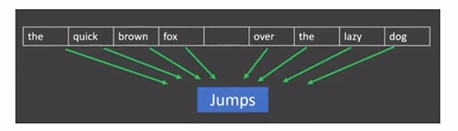

- 分析
- 图中窗口大小为9, 使用前后4个词汇对目标词汇进行预测。

- CBOW模式下的word2vec过程说明：

  - 假设我们给定的训练语料只有一句话: Hope can set you free (愿你自由成长)，窗口大小为3，因此模型的第一个训练样本来自Hope can set，因为是CBOW模式，所以将使用Hope和set作为输入，can作为输出，在模型训练时，Hope, can, set等词汇都使用它们的one-hot编码。如图所示: 每个one-hot编码的单词与各自的变换矩阵(即参数矩阵3x5, 这里的3是指最后得到的词向量维度)相乘之后再相加, 得到上下文表示矩阵(3x1)。

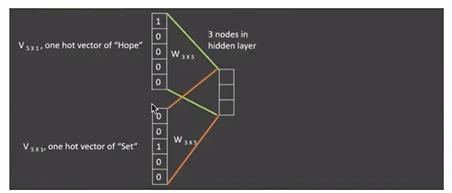

- 接着，将上下文表示矩阵与变换矩阵(参数矩阵5x3, 所有的变换矩阵共享参数)相乘，得到5x1的结果矩阵，它将与我们真正的目标矩阵即can的one-hot编码矩阵(5x1)进行损失的计算，然后更新网络参数完成一次模型迭代。

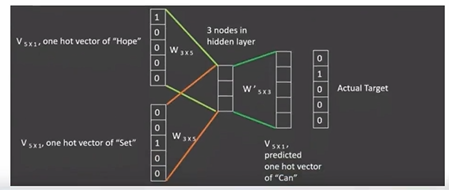